## **Introdução**

Este notebook tem como objetivo aplicar os dados de calibração de temperatura aos resultados de difração, permitindo uma análise mais precisa em relação ao comportamento real da amostra durante o experimento. O foco principal é substituir a temperatura obtida pelo cryojet pela temperatura real medida pelo termopar.

### **Importando as bibliotecas necessárias**


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns
from glob import glob
import numpy as np

# Configuração de fonte para o plot dos dados
plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 12})


## **Importando os dados**


Nesse projeto serão utilizados dois conjuntos de dados: 

- **``PROC``**: Essa pasta contém os dados de difração de raio X para cada um dos crioprotetores, com os dados crus já processados. Dentro das pastas dos crioprotetores nós temos a seguinte estrutura para os arquivos _.csv_ do dados:

    - **nome do arquivo**: no nome do arquivo há as informações: tipo de crioprotetor utilizado, a temperatura em que houve a medição (é utilizado o valor de temperatura durante o primeiro instante dos 23 segundos de medição) e o número na sequência de aquisição. 
 
    - **2theta (degree)**: é o ângulo de difração medido na difração de raio X.

    - **Intensity**: é radiação do espalhamento medida em uma área.

- **``Calibração``**: A tabela de calibração contém os valores de temperatura obtidos por um termopar, de forma que esses valores representam a temperatura da amostra durante as medições, ao mesmo tempo em que estavam submetidas ao cryojet. Dessa meneira, é possível notar a diferença entre as temperaturas medidas pelo cryojet e pelo termopar. Estrutura:

    - **cryojet_current_temp[K]**: é a temperatura medida pelo cryojet, em Kelvin.

    - **Setpoint[K]**: é a temperatura alvo estabelecida para o cryojet.

    - **T1[K]**: é a temperatura medida pelo termopar.

    - **Time[h-m-s]**: é o registro do instante da medição em hora-minuto-segundo.

**``OBS``**: Os dados de calibração vieram a princípio em um formato de pdf e foram extraídos e passados para _.csv_. (``extracao_dados_calib_temp.ipynb``)

Como o tempo decorrido desde o início das medições pode ser um dado útil para o alinhamento dos datasets, será utilizado o período de aquisição que havia nos dados crus (*acquire_period*) para encontrar o tempo decorrido desde a primeira medição.

In [25]:
periodo_aqu = 23.200001

### **PROC**


Estão sendo utilizados os arquivos do crioprotetor vs55 como exemplo para o desenvolvimento do código. Primeiramente foram listados todos os arquivos *.csv* da pasta para serem parte do conjunto de dados ``df_proc``, juntamente com as informações da medição: 

- [``nome``]: o nome do arquivo;

- [``temperatura[K]``]: o valor de temperatura (medido pelo cryojet); 

- [``step``]: o número na sequência; 
 
- [``tempo_decorrido[s]``]: o tempo decorrido. 
 
Como existem dados em que os valores de temperatura eram alterados durante a medição, os arquivos que representam esse tipo de medição receberam o nome com *"RAMP"* nele. (Isso impacta na extração de informações no nome do arquivo, havendo mudanças nos índices)

In [26]:
path_proc = "../dados/proc/main_folder_vs55/merge_files"
files_data_proc = []

for path_arquivo_csv in glob(f"{path_proc}/*.csv"):
    df = pd.read_csv(path_arquivo_csv)
    nome = path_arquivo_csv.split("\\")[-1].replace(".csv", "")

    if "RAMP" in nome:
        temp = nome.split("_")[2].replace("Kelvin", "")
    else:
        temp = nome.split("_")[1].replace("Kelvin", "")

    step = int(nome.split("_")[-2])

    files_data_proc.append(
        {"nome": nome, "temperatura[K]": float(temp), "step": step, "dados": df}
    )

df_proc = pd.DataFrame(files_data_proc)
df_proc = df_proc.sort_values(by="step").reset_index(drop=True)

df_proc["tempo_decorrido[s]"] = df_proc.index * periodo_aqu

display(df_proc[["nome", "temperatura[K]", "step", "tempo_decorrido[s]"]].head())
print(f"\nLinhas: {df_proc.shape[0]}, Colunas: {df_proc.shape[1]}")


,nome,temperatura[K],step,tempo_decorrido[s]
0,vs55_RAMP_296Kelvin_128_MERGE,296.0,128,0.000000
1,vs55_RAMP_285Kelvin_130_MERGE,285.0,130,23.200001
2,vs55_RAMP_279Kelvin_132_MERGE,279.0,132,46.400002
3,vs55_RAMP_272Kelvin_134_MERGE,272.0,134,69.600003
4,vs55_RAMP_263Kelvin_136_MERGE,263.0,136,92.800004



Linhas: 65, Colunas: 5


### **Tabela de Calibração**

Assim como no ``df_proc``, nessa tabela de calibração, ``df_calib``, foi adicionada a coluna de tempo decorrido, de forma que foi necessário converter os horários, que estavam no formato de [hora-minuto-segundo] para segundos. 

In [27]:
path_tabela = "../dados/extracted/tabela_extraida_calib_temp.csv"

df_calib = pd.read_csv(path_tabela)

tempos_dt = pd.to_datetime(df_calib["Time[h-m-s]"], format="%H-%M-%S")
tempos_decorridos = tempos_dt - tempos_dt.iloc[0]

df_calib["tempo_decorrido[s]"] = tempos_decorridos.dt.total_seconds()

display(df_calib.head())
print(f"Linhas: {df_calib.shape[0]}, Colunas: {df_calib.shape[1]}")

,cryojet_current_temp[K],Setpoint[K],T1[K],Time[h-m-s],tempo_decorrido[s]
0,296.44,296.44,299.350001,11-30-14,0.0
1,296.16,296.20,299.449999,11-30-24,10.0
2,295.82,295.85,299.449999,11-30-34,20.0
3,295.69,295.69,299.550000,11-30-44,30.0
4,295.56,80.00,299.350001,11-30-54,40.0


Linhas: 608, Colunas: 5


Para realizar o processo de alinhamento dos dados baseando-se na equivalência das temperaturas do cryojet em ambas as medições, é necessário dividir os dados entre as fases de resfriamento e de aquecimento. Visto que os dados de calibração contém ambas as curvas, um valor de temperatura de referência no ``df_proc`` poderia encontrar dois pontos de temperatura próxima na claibração. Sem a distinção, há o risco de associar dois processos de evolução temporal e térmica distintos para a amostra, considerando que para a que equivalência seja válida os dados comparados devem pertencer à mesma fase do ciclo térmico.

Para encontrar o valor do ponto de inflexão da curva foi utilizado o valor mínimo de temperatura, que foi uma boa aproximação para os dados do crioprotetor utilizado. Esse processo não é muito robusto e exige uma análise acerca dos dados utilizados.

In [28]:
idx_min_temp_calib = df_calib["cryojet_current_temp[K]"].argmin()
df_calib_resf = df_calib[:idx_min_temp_calib].copy()
df_calib_aquec = df_calib[idx_min_temp_calib:].copy()
min_temp_calib = df_calib["cryojet_current_temp[K]"][idx_min_temp_calib]

idx_min_temp_proc = df_proc["temperatura[K]"].argmin()
df_proc_resf = df_proc[:idx_min_temp_proc].copy()
df_proc_aquec = df_proc[idx_min_temp_proc:].copy()
min_temp_proc = df_proc["temperatura[K]"][idx_min_temp_proc]

print("--- Dataframes de Calibração ---")
print(f"Resfriamento: linhas = {df_calib_resf.shape[0]}; colunas = {df_calib_resf.shape[1]}")
print(f"Aquecimento: linhas = {df_calib_aquec.shape[0]}; colunas = {df_calib_aquec.shape[1]}")
print(f"Min. Temp = {min_temp_calib}")

print("\n--- Dataframes PROC ---")
print(f"Resfriamento: linhas = {df_proc_resf.shape[0]}; colunas = {df_proc_resf.shape[1]}")
print(f"Aquecimento: linhas = {df_proc_aquec.shape[0]}; colunas = {df_proc_aquec.shape[1]}")
print(f"Min. Temp = {min_temp_proc}")



--- Dataframes de Calibração ---
Resfriamento: linhas = 159; colunas = 5
Aquecimento: linhas = 449; colunas = 5
Min. Temp = 79.96000000000001

--- Dataframes PROC ---
Resfriamento: linhas = 27; colunas = 5
Aquecimento: linhas = 38; colunas = 5
Min. Temp = 80.0


## **Alinhamento dos Dados**


Primeiramente, foi pensado em definir um ponto inicial de alinhamento,  visto que as medições de difração e de calibração podem apresentar instantes iniciais distintos. Logo, para sincronizá-las, pareou-se a temperatura inicial da medição de difração com a temperatura mais próxima da calibração. [Processo realizado na célula abaixo]

Exemplo: Se $T_{calib} = [296.44, 296.16, 295.82, \dots]$ e $T_{proc\_inicial} = 296$ K, determina-se $T_{calib\_inicial} = 296.16$ K.



Estabelecido o ponto inicial, a primeira tentativa de alinhamento utilizou o tempo decorrido como critério de equivalência. Dessa forma, cada ponto de difração foi associado à medição do termopar mais próxima temporalmente. Além disso, como maneira de verificar o tamanho do erro de uma aproximação, calculou-se a diferença entre as temperaturas do cryojet nos dados processados e nos de calibração após o alinhamento. 

No entanto, essa abordagem não se mostrou muito boa, uma vez que, embora a diferença inicial fosse pequena, o erro divergiu significativamente ao longo do experimento, atingindo diferenças de mais 80 K. Esse comportamento indica que, provavelmente, que as taxas de aquecimento e resfriamento variam entre as medições, causando uma dessincronização entre a temperatura da amostra e da calibração.

Como alternativa, foi utilizada a temperatura do cryojet como base para o alinhamento. Para cada ponto de referência nos dados processados, buscou-se o valor de temperatura mais próximo nos dados de calibração. Também, como uma forma de ver a evolução do erro, foi feita diferença entre os instantes de tempo de ambos os conjuntos de dados.

In [29]:
temp_inical_proc = df_proc["temperatura[K]"][0]

idx_ponto_inical_calib = np.abs(df_calib_resf["cryojet_current_temp[K]"] - temp_inical_proc).idxmin()
t_inicial_calib = df_calib["tempo_decorrido[s]"].loc[idx_ponto_inical_calib]

df_calib_corr = df_calib[idx_ponto_inical_calib:].copy()
df_calib_corr["tempo_decorrido[s]"] -= t_inicial_calib
idx_min_temp_calib_corr = df_calib_corr["cryojet_current_temp[K]"].idxmin()

df_calib_resf = df_calib_corr.loc[:idx_min_temp_calib_corr].copy()
df_calib_aquec = df_calib_corr.loc[idx_min_temp_calib_corr:].copy()

Fazendo agora esse processo de alinhamento pela temperatura do cryojet.

Se for do interesse fazer alinhamento com base no tempo decorrido é necessário remover os condicionais e encontrar o índice por: *``idx_prox = np.abs(df_calib["tempo_decorrido[s]"] - t_proc).idxmin()``*

In [30]:
dados = []

for i in range(len(df_proc)):        

    t_proc = df_proc["tempo_decorrido[s]"][i]
    temp_cryojet_proc = df_proc["temperatura[K]"][i]

    # Resfriamento
    if i <= idx_min_temp_proc: 
        idx_prox = np.abs(df_calib_resf["cryojet_current_temp[K]"] - temp_cryojet_proc).idxmin()
        # idx_prox = np.abs(df_calib["tempo_decorrido[s]"] - t_proc).idxmin()

    # Aquecimento
    else: 
        idx_prox = np.abs(df_calib_aquec["cryojet_current_temp[K]"] - temp_cryojet_proc).idxmin()
        # idx_prox = (df_calib_aquec["cryojet_current_temp[K]"] - t_proc).index[idx_prox]
     
    dado_calib = df_calib_corr.loc[idx_prox]
    
    t_calib = dado_calib["tempo_decorrido[s]"]
    temp_cryojet_calib = dado_calib["cryojet_current_temp[K]"]
    temp_t1_calib = dado_calib["T1[K]"]

    diff_temp_cryojet = temp_cryojet_proc - temp_cryojet_calib
    diff_t = t_proc - t_calib

    dados.append({
        "t_decorrido_proc": t_proc,
        "t_decorrido_calib": t_calib,
        "temp_t1": temp_t1_calib,
        "temp_cryojet_calib": temp_cryojet_calib,
        "temp_cryojet_proc": temp_cryojet_proc,
        "diff_temp_cryojet": diff_temp_cryojet, 
        "diff_t": diff_t
    })  

df_temp_corr = pd.DataFrame(dados)

display(df_temp_corr.head())
print(f"Shape: {df_temp_corr.shape}")

media_diff_temp_cryojet = np.mean(df_temp_corr["diff_temp_cryojet"])
std_diff_temp_cryojet = np.std(df_temp_corr["diff_temp_cryojet"])

media_diff_t = np.mean(df_temp_corr["diff_t"])
std_diff_t = np.std(df_temp_corr["diff_t"])

print(f"Média e desvio padrão da diferença de temperatura do cryojet: {media_diff_temp_cryojet:.6f} +/- {std_diff_temp_cryojet:.6f}")
print(f"Média e desvio padrão da diferença de tempo: {media_diff_t:.6f} +/- {std_diff_t:.6f}")

,t_decorrido_proc,t_decorrido_calib,temp_t1,temp_cryojet_calib,temp_cryojet_proc,diff_temp_cryojet,diff_t
0,0.000000,0.0,299.449999,296.16,296.0,-0.16,0.000000
1,23.200001,51.0,291.250000,286.03,285.0,-1.03,-27.799999
2,46.400002,71.0,286.850000,280.13,279.0,-1.13,-24.599998
3,69.600003,101.0,280.350000,271.78,272.0,0.22,-31.399997
4,92.800004,131.0,274.250000,262.98,263.0,0.02,-38.199996


Shape: (65, 7)
Média e desvio padrão da diferença de temperatura do cryojet: 0.024154 +/- 0.379947
Média e desvio padrão da diferença de tempo: -1243.076891 +/- 838.286855


#### **Aplicando a temperatura de calibração**

Substituindo os valores de temperatura do cryojet da tabela dos dados processados pelos valores de temperatura do termopar que foram alinhados.

In [31]:
df_proc_final = df_proc.copy()
df_proc_final["temperatura[K]"] = df_temp_corr["temp_t1"].values

display(df_proc_final.head())

,nome,temperatura[K],step,dados,tempo_decorrido[s]
0,vs55_RAMP_296Kelvin_128_MERGE,299.449999,128,2theta (degree) Intensity 0 ...,0.000000
1,vs55_RAMP_285Kelvin_130_MERGE,291.250000,130,2theta (degree) Intensity 0 ...,23.200001
2,vs55_RAMP_279Kelvin_132_MERGE,286.850000,132,2theta (degree) Intensity 0 ...,46.400002
3,vs55_RAMP_272Kelvin_134_MERGE,280.350000,134,2theta (degree) Intensity 0 ...,69.600003
4,vs55_RAMP_263Kelvin_136_MERGE,274.250000,136,2theta (degree) Intensity 0 ...,92.800004


## **Plotando os dados**

Agora, com as temperaturas devidamente calibradas e os dados alinhados, passamos para a visualização dos difratogramas. 

O objetivo é observar a evolução dos perfis de difração à medida que a temperatura da amostra varia, permitindo a identificação de mudanças estruturais, visto que quando há a formação de cristais são formados picos de difração. 

Para possibilitar a comparação de vários perfis em um único gráfico, foi aplicado um *offset* no eixo $y$, permitindo observar mais claramente o surgimento ou desaparecimento de picos ao longo do ciclo térmico. Foi também aplicado um mapa de cores que representa a temperatura, para deixar a análise mais "intuitiva". Além disso, os dados foram plotados de forma sequencial, em que a curva mais baixa representa a primeira aquisição e a última curva a última aquisição.

É válido dizer que os valores do eixo $y$ serão omitidos visto que com a adição do offset eles não se tornam mais tão representativos, embora isso não seja um problema para a análise em questão, que busca visualizar a formação de picos. 


In [32]:
temperaturas = df_proc_final["temperatura[K]"].values
temp_min = min(temperaturas)
temp_max = max(temperaturas)

norm = mcolors.Normalize(vmin=temp_min, vmax=temp_max)
cmap = plt.colormaps.get_cmap("viridis")

offset = 0
offset_step = 1e10

fig = plt.figure(figsize=(13, 20), dpi=600)
ax1 = fig.add_subplot(1, 1, 1)

offsets = []
steps = []
labels_temp = []

for i, linha in df_proc_final.iterrows():
    nome = linha["nome"]
    temp = linha["temperatura[K]"]
    step = linha["step"]
    df = linha["dados"]

    X = df["2theta (degree)"]
    y = df["Intensity"]

    cor = cmap(norm(temp))
    ax1.plot(X, y + offset, linewidth=0.9, color=cor)

    offsets.append(offset)
    steps.append(f"{step}")
    labels_temp.append(f"{temp:.3f}")

    offset += offset_step

plt.title("V55", fontsize=16)
ax1.set_xlabel("2theta (degree)")
ax1.set_ylabel("Intensity + offset (a.u.)")
ax1.set_xlim(0)
ax1.set_ylim(bottom=0, top=offset)

ax1.set_yticks([])
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(which="major", direction="out", length=7, width=1.2)
ax1.tick_params(which="minor", direction="out", length=4, width=0.8)
ax1.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.4)

# eixo y à direita
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(offsets)
ax2.set_yticklabels(labels_temp, fontsize=10)
# ax2.set_yticklabels(steps, fontsize=10)
ax2.set_ylabel("Temperature [K]", labelpad=10)
# ax2.set_ylabel("Steps (a.u.)", labelpad=10)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax1, pad=0.12, aspect=25)
cbar.set_label("Temperature (K)", labelpad=10)

cbar.ax.yaxis.set_minor_locator(AutoMinorLocator())
cbar.ax.tick_params(which="major", direction="out", length=5, width=1)
cbar.ax.tick_params(which="minor", direction="out", length=3, width=0.8)

plt.show()

No gráfico é possível observar que por volta de 200 a 235 graus provavelmente houve a cristalização, em razão da formação de picos de difração

### **Plotando uma matriz de correlação**


Definidos os pontos em que provavlemente houve uma crstalização e 

A contrução da matriz de correlação, foi feita como uma forma de investigar as relações estatísticas entre as intensidades em diferentes ângulos de difração sob diferentes condições térmicas. Isso, a fim de verificar se as variações de intensidade em determinados ângulos acompanham as flutuações de outros, o que pode ajudar a indicar que houve um novo padrão de difração. 

O processo de cálculo e visualização necessitou dos seguintes procedimentos:

- Filtragem: utilizou-se parâmetros de busca (``target_temp`` e ``target_2theta``) para isolar uma região de interesse nos dados.

- Cálculo: a matriz é gerada utilizando o método de Pearson (``method="pearson"``), que quantifica a força e a direção da relação linear entre os pares de intensidades nos ângulos selecionados.

- Visualização: o gráfico foi feito com a função ``sns.heatmap``.

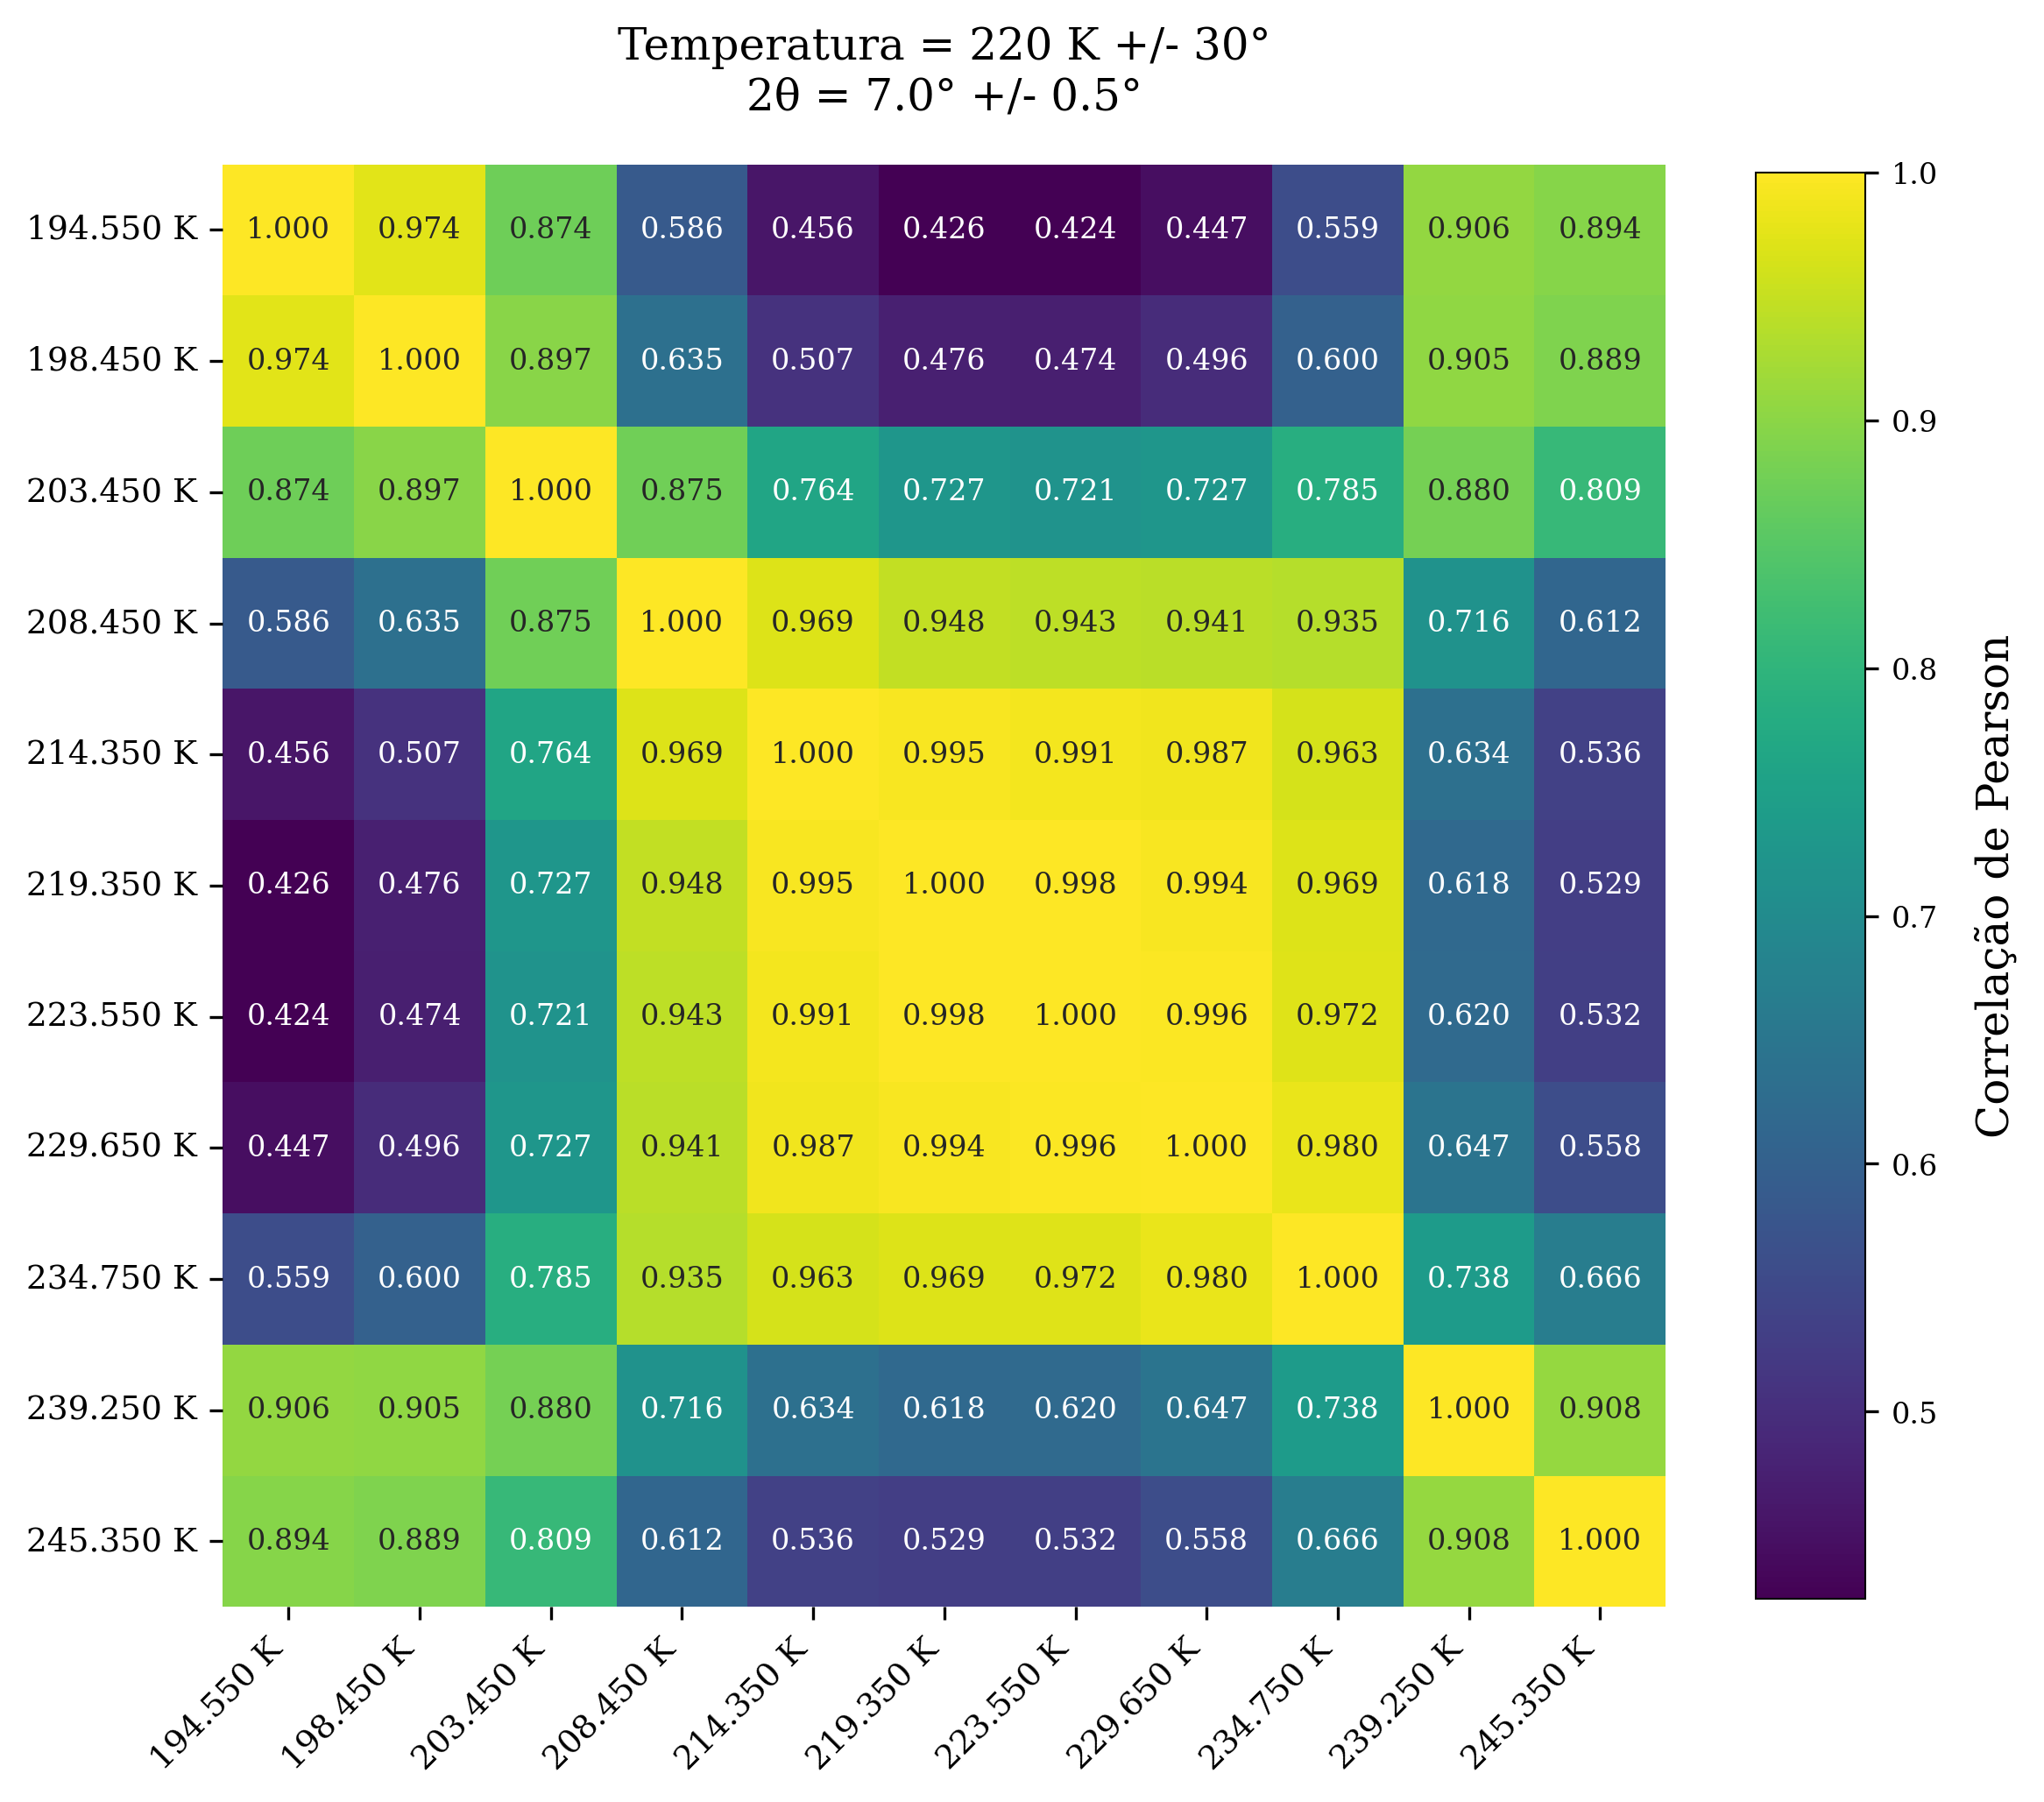

In [33]:
target_temp = 220
tol_temp = 30

target_2theta = 7.0
tol_2theta = 0.5

dados_filtrados = {}

for i, linha in df_proc_final.iterrows():
    nome = linha["nome"]
    temp = linha["temperatura[K]"]
    step =linha["step"]
    df = linha["dados"]

    if (target_temp - tol_temp) <= temp <= (target_temp + tol_temp) and step >= 200:
        df_filtro = df[
            (df["2theta (degree)"] >= target_2theta - tol_2theta)
            & (df["2theta (degree)"] <= target_2theta + tol_2theta)
        ]

        dados_filtrados[f"{temp:.3f} K"] = df_filtro["Intensity"].values


df_matrix = pd.DataFrame(dados_filtrados)
corr_matrix = df_matrix.corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

heatmap = sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="viridis",
    annot=True,
    fmt=".3f",
    annot_kws={"size": 8},
    square=True,
    cbar_kws={
        "shrink": 0.92,
        "aspect": 13
    }
)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)

cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(0.5)
cbar.set_label("Correlação de Pearson", labelpad=10)

ax.set_title(
    f"Temperatura = {target_temp} K +/- {tol_temp}°\n2θ = {target_2theta}° +/- {tol_2theta}°",
    pad=15,
    fontsize=12,
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.show()